In [2]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer

In [4]:
df = pd.read_csv('train.csv',usecols=['Age','Fare','Survived'])

In [5]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [6]:
# fillup missing values in Age column with median value of Age column
df['Age'].fillna(df['Age'].mean(), inplace=True)

C:\Users\Admin\AppData\Local\Temp\ipykernel_6432\890116328.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(), inplace=True)


In [8]:
df.sample(5)

,Survived,Age,Fare
754,1,48.0,65.0000
455,1,29.0,7.8958
799,0,30.0,24.1500
139,0,24.0,79.2000
679,1,36.0,512.3292


In [9]:
# split data into train and test sets
X=df.iloc[:,1:3]
Y=df.iloc[:,0]
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=0)

Text(0.5, 1.0, 'Age Distribution Before Transformation')

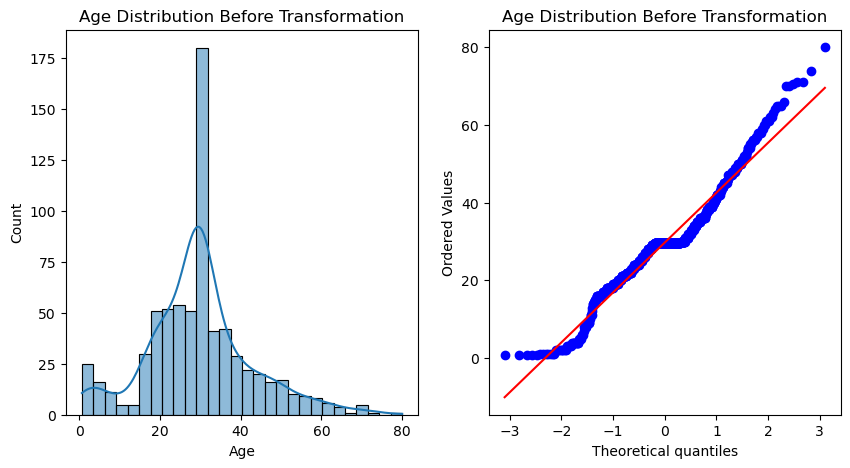

In [12]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
sns.histplot(X_train['Age'], kde=True)
plt.title('Age Distribution Before Transformation')

plt.subplot(1,2,2)
stats.probplot(X_train['Age'], dist="norm", plot=plt)
plt.title('Age Distribution Before Transformation')

Text(0.5, 1.0, 'Fare Distribution Before Transformation')

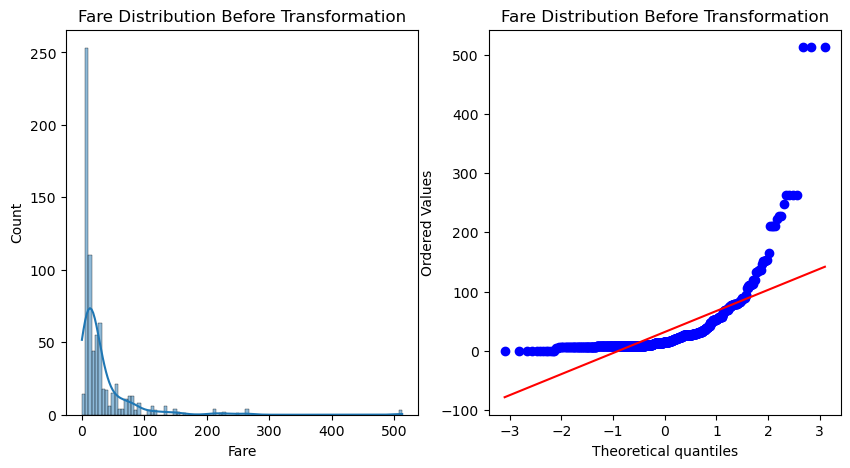

In [13]:
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
sns.histplot(X_train["Fare"], kde=True)
plt.title("Fare Distribution Before Transformation")

plt.subplot(1, 2, 2)
stats.probplot(X_train["Fare"], dist="norm", plot=plt)
plt.title("Fare Distribution Before Transformation")

In [14]:
clf=LogisticRegression()
clf2=DecisionTreeClassifier()

In [15]:
clf.fit(X_train,Y_train)
clf2.fit(X_train,Y_train)

DecisionTreeClassifier()

In [16]:
y_pred=clf.predict(X_test)
y_pred2=clf2.predict(X_test)

print("Accuracy of Logistic Regression:",accuracy_score(Y_test,y_pred))
print("Accuracy of Decision Tree:",accuracy_score(Y_test,y_pred2))

Accuracy of Logistic Regression: 0.6983240223463687
Accuracy of Decision Tree: 0.6759776536312849


In [17]:
trf=FunctionTransformer(np.log1p)

In [18]:
x_train_transformed = trf.fit_transform(X_train)
x_test_transformed = trf.transform(X_test)

In [21]:
clf=LogisticRegression()
clf2=DecisionTreeClassifier()

clf.fit(x_train_transformed,Y_train)
clf2.fit(x_train_transformed,Y_train)

y_pred=clf.predict(x_test_transformed)
y_pred2=clf2.predict(x_test_transformed)

# Accuracy of Logistic Regression:",accuracy_score(Y_test,y_pred))
print("Accuracy of LLogistic Regression:",accuracy_score(Y_test,y_pred))
print("Accuracy of Decision Tree:", accuracy_score(Y_test, y_pred2))

Accuracy of LLogistic Regression: 0.7039106145251397
Accuracy of Decision Tree: 0.664804469273743


In [24]:
X_transformed = trf.fit_transform(X)

clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

print("Cross-validation scores for Logistic Regression:", np.mean(cross_val_score(clf, X_transformed, Y,scoring='accuracy', cv=5)))
print(
    "Cross-validation scores for Decision Tree:",
    np.mean(cross_val_score(clf2, X_transformed, Y, scoring="accuracy", cv=5))
)

Cross-validation scores for Logistic Regression: 0.6780114242671521
Cross-validation scores for Decision Tree: 0.6442219571903836


Text(0.5, 1.0, 'Age Distribution After Transformation')

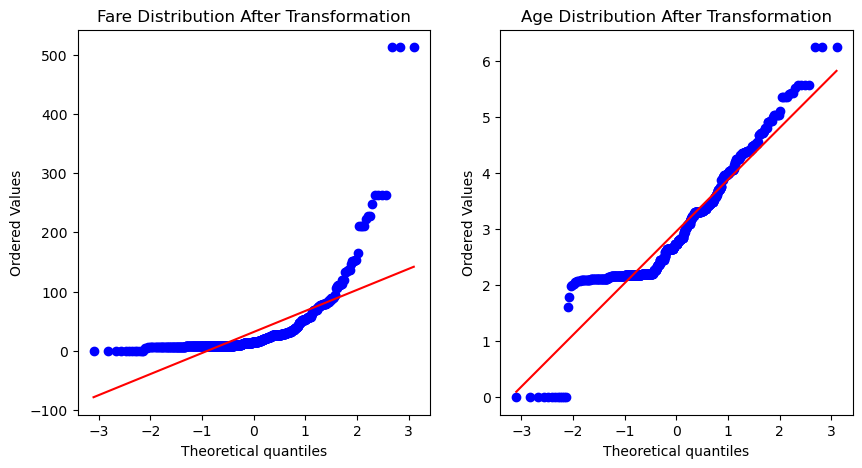

In [26]:
plt.figure(figsize=(10, 5))    

plt.subplot(1, 2, 1)
stats.probplot(X_train['Fare'], dist="norm", plot=plt)
plt.title('Fare Distribution After Transformation')

plt.subplot(1, 2, 2)
stats.probplot(x_train_transformed['Fare'], dist="norm", plot=plt)
plt.title('Age Distribution After Transformation')

Text(0.5, 1.0, 'Age Distribution After Transformation')

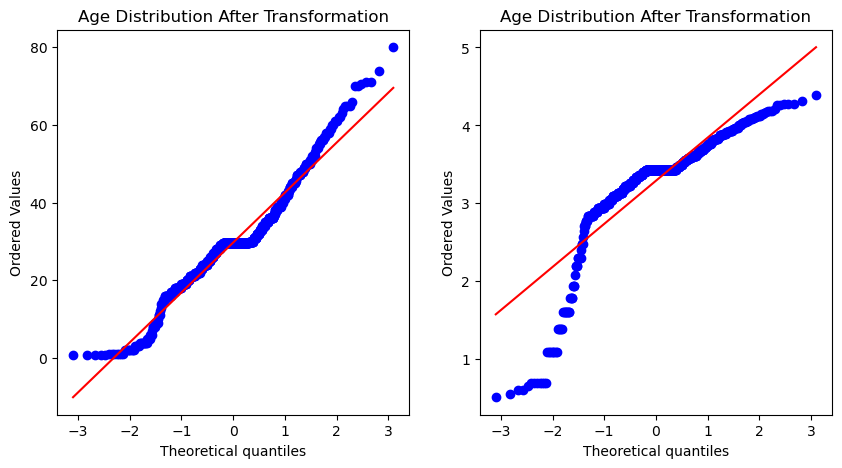

In [27]:
# for age
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
stats.probplot(X_train["Age"], dist="norm", plot=plt)
plt.title("Age Distribution After Transformation")

plt.subplot(1, 2, 2)
stats.probplot(x_train_transformed["Age"], dist="norm", plot=plt)
plt.title("Age Distribution After Transformation")